# LearnM8 Quickstart

Learn how to run your first active learning experiment in 10 minutes.

**What you'll learn:**
- Load a compound library
- Configure an active learning experiment
- Inspect and visualize results

**Time estimate:** 10 minutes

In [2]:
# Imports
from learnm8 import run_active_learning
import polars as pl
import matplotlib.pyplot as plt

# Configuration
plt.rcParams['figure.dpi'] = 100
print("✓ Setup complete")

✓ Setup complete


In [3]:
# Load AmpC dataset: 1000 real drug-like compounds with docking scores
from pathlib import Path
import pandas as pd
compounds_path = Path('../data/ampc_1k_with_scores.csv')

compounds = pd.read_csv(compounds_path)

print(f"Loaded {len(compounds)} compounds")
print(f"Columns: {compounds.columns}")
print(f"\nFirst few compounds:")
print(compounds.head(3))
print(f"\nDockscore statistics:")
print(f"  Range: {compounds['dockscore'].min():.2f} to {compounds['dockscore'].max():.2f}")
print(f"  Mean: {compounds['dockscore'].mean():.2f}")

Loaded 1000 compounds
Columns: Index(['ID', 'SMILES', 'dockscore'], dtype='object')

First few compounds:
                 ID                                          SMILES  dockscore
0  ZINC000155737055  C[C@H]1COCCN1C(=O)N[C@H](c1cccc(F)c1F)C(F)(F)F     -25.51
1  ZINC000135070840    C=C[C@@](C)(CC)C(=O)NC[C@@](C)(O)c1cc(C)oc1C     -27.18
2  ZINC000124377651           CN(CC1(O)CCCC1)C(=O)[C@H]1CCCc2sccc21     -28.99

Dockscore statistics:
  Range: -73.74 to -3.55
  Mean: -30.96


In [ ]:
# Run active learning with CSVOracle (BENCHMARK MODE)
# Benchmark mode: Ground truth values are known (dockscore column in CSV)
# This allows evaluation of active learning performance via enrichment metrics

# Goal: Find compounds with low docking scores (strong binders)
results = run_active_learning(
    compound_pool=compounds_path,        # DataFrame with compounds to screen
    oracle=compounds_path,                # CSVOracle: uses 'dockscore' column as ground truth
    learner='rf',                    # Random Forest (no uncertainty quantification)
    target_col='dockscore',          # Column name for target property
    featurizer='morgan',        # Morgan fingerprints for molecular representation
    strategy='greedy',               # Acquisition strategy: select compounds with best predictions
    n_cycles=5,                      # Number of active learning cycles
    batch_fraction=0.1,              # Select 10% of remaining pool per cycle
    score_direction='lower',
	output_dir='results/01_quickstart'          # Lower docking scores indicate stronger binding
)

print(f"✓ Experiment complete!")
print(f"  Cycles: {len(results['cycle_metrics'])}")
print(f"  Compounds measured: {len(results['labeled_data'])}")
print(f"  Best dockscore found: {min([cycle['best_so_far'] for cycle in results['cycle_metrics']]):.2f}")

# Note: For uncertainty-based strategies (ucb, ei, thompson), use 'rf_ensemble' learner:
# learner='rf_ensemble' provides uncertainty estimates via ensemble disagreement

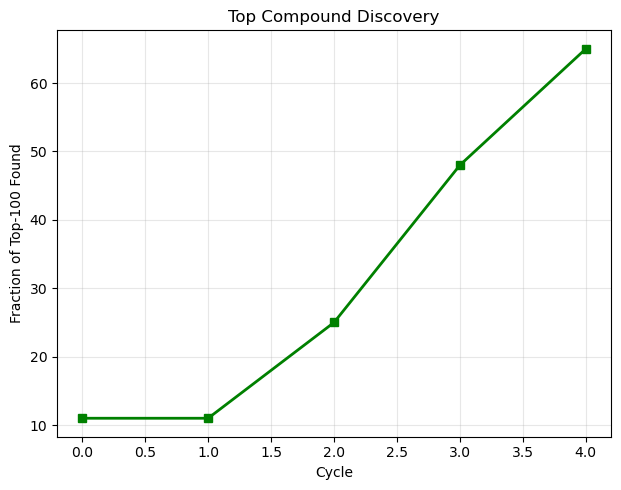


✓ Final Performance:
  Top-100 discovered: 6500.0%


In [12]:
# View cycle metrics (BENCHMARK MODE: enrichment metrics available)
# Because ground truth is known, we can evaluate active learning performance
import pandas as pd
metrics_df = pd.DataFrame(results['cycle_metrics'])

# Enrichment Factor: How much better than random selection
# Top-K Discovered: Fraction of best compounds found so far
plt.figure(figsize=(12, 5))

# Plot: Top-K Discovery
plt.subplot(1, 2, 2)
plt.plot(metrics_df['cycle'], metrics_df['top_10_pct_discovery'], marker='s', linewidth=2, color='green')
plt.xlabel('Cycle')
plt.ylabel('Fraction of Top-100 Found')
plt.title('Top Compound Discovery')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ Final Performance:")
print(f"  Top-100 discovered: {metrics_df.iloc[-1]['top_10_pct_discovery']:.1%}")

## Summary

You just ran your first active learning experiment on 1000 real drug-like molecules!

**What we did:**
- Loaded 1K compounds from AmpC beta-lactamase docking dataset
- Used CSVOracle (**BENCHMARK MODE**) to evaluate docking scores
- Applied Random Forest with Morgan fingerprints
- Found strong binders efficiently through active selection

**Why Benchmark Mode?**
- Ground truth values (dockscores) are **known** and stored in the CSV
- Allows evaluation of active learning performance via **enrichment metrics**
- Can report: top-K discovery
- Simulates retrospective analysis of screening campaigns

**Key Concepts:**
- `run_active_learning()`: Main API entry point
- `learner='rf'`: Random Forest model (use 'rf_ensemble' for uncertainty)
- `featurizer='morgan'`: Molecular fingerprints for ML
- `strategy='greedy'`: Select compounds with best predictions
- `n_cycles=5`: Number of selection rounds
- `batch_fraction=0.1`: Select 10% of pool per cycle
- `score_direction='lower'`: Optimize for lower docking scores (stronger binding)

**Dataset:** 1000 compounds randomly sampled from AmpC 30K dataset with docking scores

**Benchmark vs Run Mode:**
- **Benchmark Mode** (Notebook 1): Ground truth known → enrichment metrics available
- **Run Mode** (Notebooks 2-4): Oracle generates values on-the-fly → only selection metrics

**Next Steps:**
- [02_custom_oracles.ipynb](02_custom_oracles.ipynb): Custom oracles in run mode
- [03_advanced_configuration.ipynb](03_advanced_configuration.ipynb): Advanced configuration
- [Documentation](../../docs/): Full API reference